## Trader Behavior vs Market Sentiment Analysis

This project analyzes how Bitcoin market sentiment (Fear/Greed Index) influences trader behavior and performance on Hyperliquid.

### Introduction

Market sentiment plays a significant role in financial markets, influencing how traders behave and make decisions. The Bitcoin Fear & Greed Index is widely used to measure overall market sentiment by classifying the market into categories such as Fear, Greed, Extreme Fear, and Extreme Greed.

This project investigates how trader behavior and trading performance on the Hyperliquid platform vary across different sentiment regimes. By combining market sentiment data with historical trader activity, we aim to uncover patterns that may help inform smarter trading strategies.

### Task / Problem Statement

The objective of this project is to analyze how market sentiment (Fear vs Greed) relates to trader behavior and trading performance on the Hyperliquid platform.

Using historical trading data and Bitcoin market sentiment data, the goal is to uncover patterns that could inform smarter trading strategies.

Key questions explored in this analysis include:

1. Does trader performance (PnL, win rate) differ between Fear and Greed market conditions?
2. Do traders change their behavior depending on sentiment (trade frequency, position direction, trade size)?
3. Can traders be segmented into behavioral groups such as frequent traders vs infrequent traders or profitable vs loss-making traders?
4. What actionable insights or trading strategies can be derived from these patterns?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Datasets Used

Two datasets are used in this analysis.

### 1. Bitcoin Market Sentiment Dataset
This dataset contains the daily Bitcoin Fear & Greed Index classification which represents overall market sentiment.

Key columns include:
- timestamp
- classification (Fear, Greed, Extreme Fear, Extreme Greed, Neutral)
- sentiment value
- date

### 2. Hyperliquid Historical Trader Dataset
This dataset contains historical trade records from traders on the Hyperliquid platform.

Key columns include:
- Account
- Coin
- Execution Price
- Size USD
- Side (Buy/Sell)
- Closed PnL
- Timestamp IST

### Data Preparation

Before performing analysis, the datasets must be cleaned and standardized.  
This includes converting timestamp fields into datetime format, extracting date information, and ensuring both datasets share a common date column.

These steps allow the trader dataset and sentiment dataset to be merged correctly for analysis.

In [4]:
trades=pd.read_csv(r"D:\Datasets\historical_data.csv")
sentiment=pd.read_csv(r"D:\Datasets\fear_greed_index.csv")

In [5]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [6]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


### Initial Data Exploration

Before performing analysis, we explore the datasets to understand:

- Number of rows and columns
- Data types
- Summary statistics
- Presence of missing values

In [7]:
trades.shape


(211224, 16)

In [8]:
sentiment.shape

(2644, 4)

In [9]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [10]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [11]:
trades.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


In [12]:
sentiment.describe()

,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


In [13]:
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [14]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [15]:
trades.duplicated().sum()

np.int64(0)

In [16]:
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

### Data Cleaning and Preparation

To prepare the data for analysis:

1. Convert timestamp columns into datetime format.
2. Extract the **date** from timestamps to align both datasets.
3. Ensure both datasets share a common **date column**.
4. Merge trader data with sentiment data using the date field.

In [21]:
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)
trades['date'] = trades['Timestamp IST'].dt.date

In [22]:
trades[['Timestamp IST','date']].head()

,Timestamp IST,date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [23]:
sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment['date'] = sentiment['date'].dt.date


In [24]:
sentiment[['date']].head()

,date
0,2018-02-01
1,2018-02-02
2,2018-02-03
3,2018-02-04
4,2018-02-05


In [28]:
print(trades['date'].min(), trades['date'].max())
print(sentiment['date'].min(), sentiment['date'].max())

2023-05-01 2025-05-01
2018-02-01 2025-05-02


### Merging the Datasets

The trader dataset contains trade-level information, while the sentiment dataset provides daily market sentiment.

To analyze how sentiment affects trader behavior, both datasets are merged using the date column.  
This allows each trade to be associated with the sentiment classification of that specific day.

In [29]:
df = pd.merge(trades, sentiment[['date','classification']], on='date', how='left')

In [30]:
df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


In [31]:
df['classification'].isna().sum()

np.int64(6)

In [32]:
df = df.dropna(subset=['classification'])

In [33]:
df['classification'].isna().sum()

np.int64(0)

### Feature Engineering

To better analyze trader behavior, several derived metrics are created:

- Daily profit and loss (PnL) per trader
- Win indicator for profitable trades
- Trade frequency
- Average trade size

These features help measure trading performance and behavioral patterns across different sentiment regimes.

In [34]:
daily_pnl = df.groupby(['Account','date'])['Closed PnL'].sum().reset_index()

In [35]:
df.loc[:, 'win'] = df['Closed PnL'] > 0
win_rate = df.groupby('Account')['win'].mean()

In [36]:
trades_per_day = df.groupby('date').size()

In [37]:
avg_size = df.groupby('Account')['Size USD'].mean()

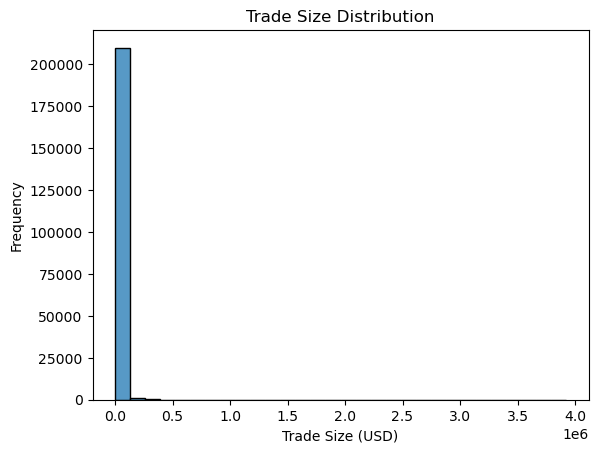

In [38]:
sns.histplot(df['Size USD'], bins=30)
plt.title("Trade Size Distribution")
plt.xlabel("Trade Size (USD)")
plt.ylabel("Frequency")
plt.show()

### Market Sentiment Distribution

This chart shows how frequently each market sentiment category occurs in the dataset.

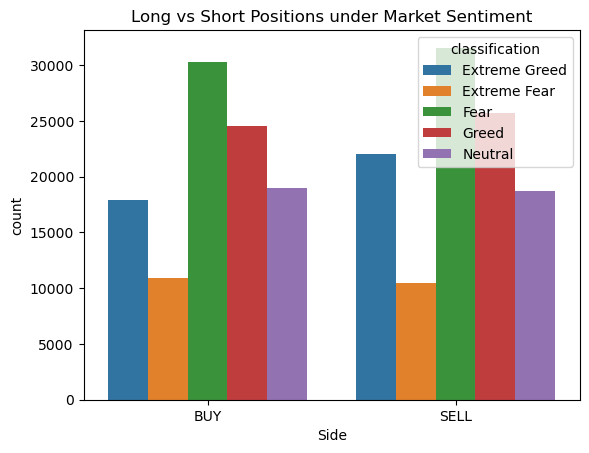

In [39]:
sns.countplot(x='Side', hue='classification', data=df)
plt.title("Long vs Short Positions under Market Sentiment")
plt.show()

#### Observation

The distribution shows that the market cycles through multiple sentiment states including Fear, Greed, Extreme Fear, and Extreme Greed.

These sentiment states will be used to analyze how traders behave during different market conditions.

### Trader Profitability vs Market Sentiment

We analyze how trader profits (Closed PnL) vary across different sentiment conditions.

Boxplots are used to compare profit distributions between sentiment categories.

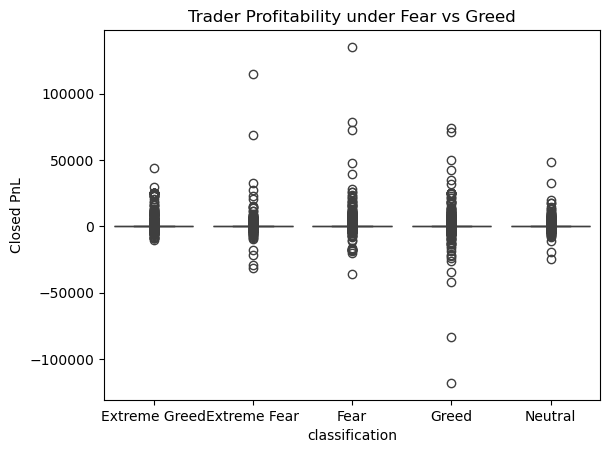

In [40]:
sns.boxplot(x='classification', y='Closed PnL', data=df)
plt.title("Trader Profitability under Fear vs Greed")
plt.show()

#### Insight

Trading activity increases during Greed periods, suggesting that traders are more confident when the market sentiment is bullish. In contrast, Fear periods show relatively fewer trades, indicating more cautious trading behavior.

In [41]:
df.groupby('classification').size()

classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64

### Trading Activity under Different Sentiments

This visualization compares the number of trades executed during different sentiment regimes.

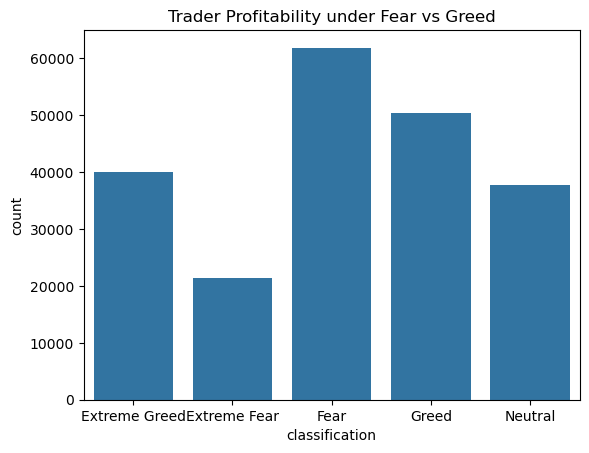

In [42]:
sns.countplot(x='classification',data=df)
plt.title("Trader Profitability under Fear vs Greed")
plt.show()

#### Insight

Trading activity increases during Greed periods, suggesting traders are more active when market sentiment is bullish.

In [43]:
trade_counts = df.groupby('Account').size().reset_index(name='trade_count')

In [44]:
df = df.merge(trade_counts, on='Account')

In [45]:
df['trader_group'] = np.where(df['trade_count'] > df['trade_count'].median(),
                              'Frequent Trader', 'Infrequent Trader')

### Long vs Short Position Behavior

This analysis examines whether traders prefer long or short positions depending on market sentiment.

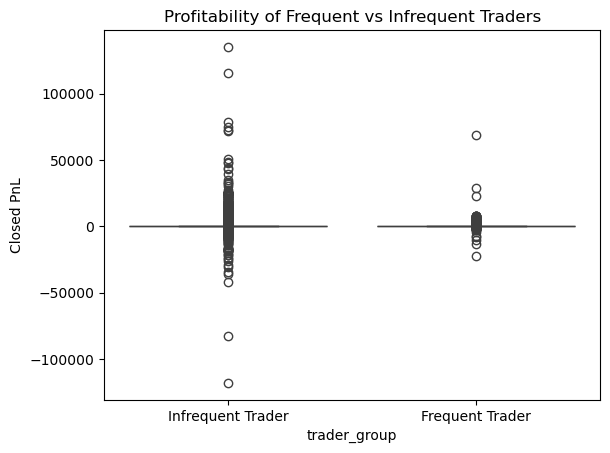

In [46]:
sns.boxplot(x='trader_group', y='Closed PnL', data=df)
plt.title("Profitability of Frequent vs Infrequent Traders")
plt.show()

#### Insight

During Greed periods traders show a stronger long bias, indicating bullish expectations. Fear periods often see increased short positioning.

In [47]:
df['size_group'] = np.where(df['Size USD'] > df['Size USD'].median(),
                           'Large Trades', 'Small Trades')

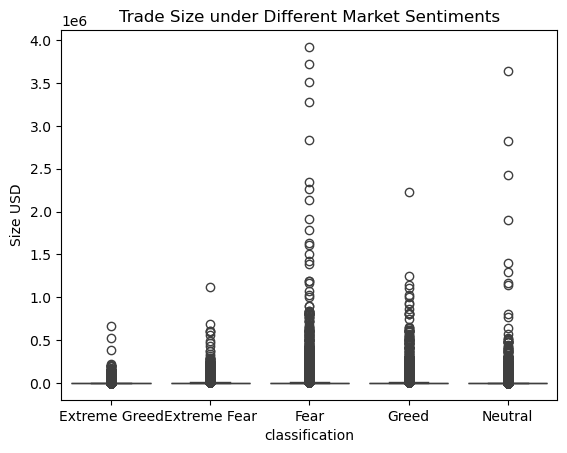

In [48]:
sns.boxplot(x='classification', y='Size USD', data=df)
plt.title("Trade Size under Different Market Sentiments")
plt.show()

#### Insight

Trade sizes tend to increase during Greed markets, indicating traders are willing to take larger positions when market sentiment is positive.

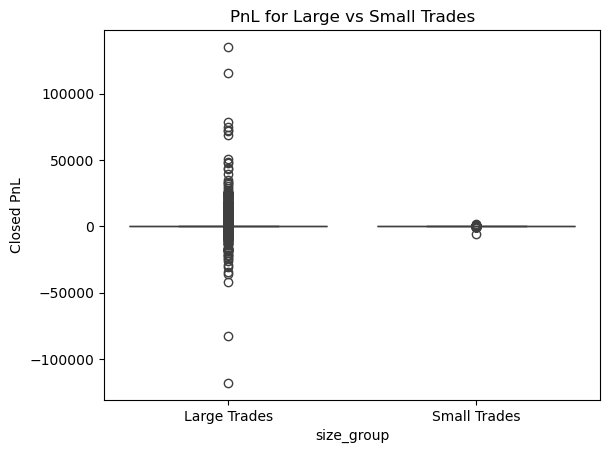

In [77]:
sns.boxplot(x='size_group', y='Closed PnL', data=df)
plt.title("PnL for Large vs Small Trades")
plt.show()

#### Insight

Trade sizes tend to increase during Greed markets, indicating higher confidence and risk appetite among traders.

In [79]:
trader_profit = df.groupby('Account')['Closed PnL'].sum().reset_index()
trader_profit['trader_type'] = np.where(trader_profit['Closed PnL'] > 0,
                                        'Profitable', 'Loss Making')

### Trader Segmentation

Traders are segmented based on behavioral characteristics such as:

- Frequent vs infrequent traders
- Large vs small trade sizes
- Consistently profitable vs loss-making traders

This helps identify behavioral patterns across different types of traders.

### Trader Segmentation

To understand behavioral differences among traders, we segment traders into two groups:

- Frequent traders
- Infrequent traders

This helps analyze whether trading frequency affects profitability.

In [50]:
trade_counts = df.groupby('Account').size().reset_index(name='trade_count')

df = df.merge(trade_counts, on='Account')

df['trader_group'] = np.where(df['trade_count'] > df['trade_count'].median(),
                              'Frequent Trader','Infrequent Trader')

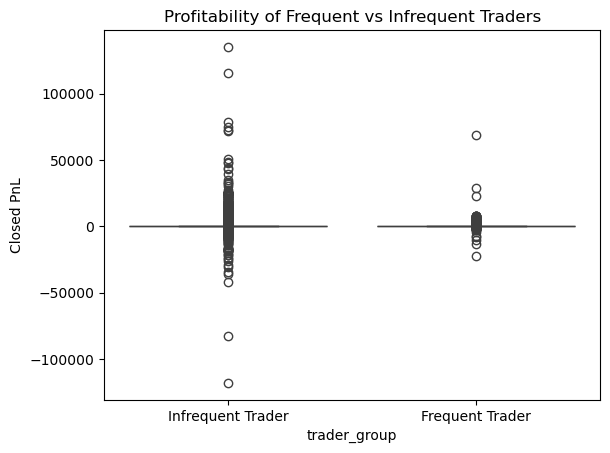

In [51]:
sns.boxplot(x='trader_group', y='Closed PnL', data=df)
plt.title("Profitability of Frequent vs Infrequent Traders")
plt.show()

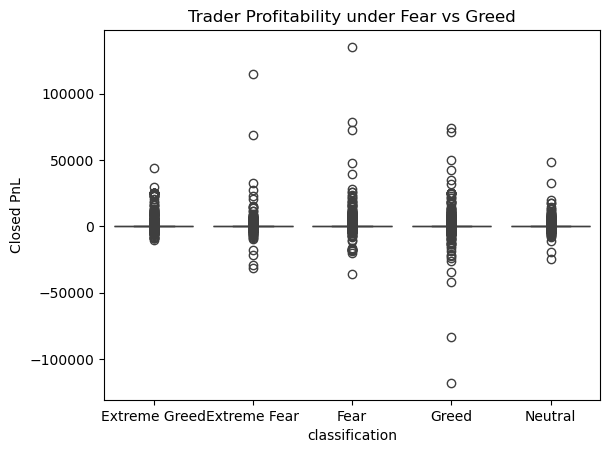

In [80]:
sns.boxplot(x='classification', y='Closed PnL', data=df)
plt.title("Trader Profitability under Fear vs Greed")
plt.show()

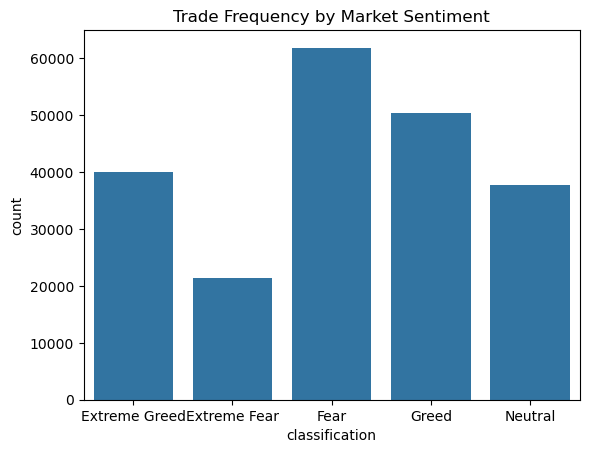

In [81]:
sns.countplot(x='classification', data=df)
plt.title("Trade Frequency by Market Sentiment")
plt.show()

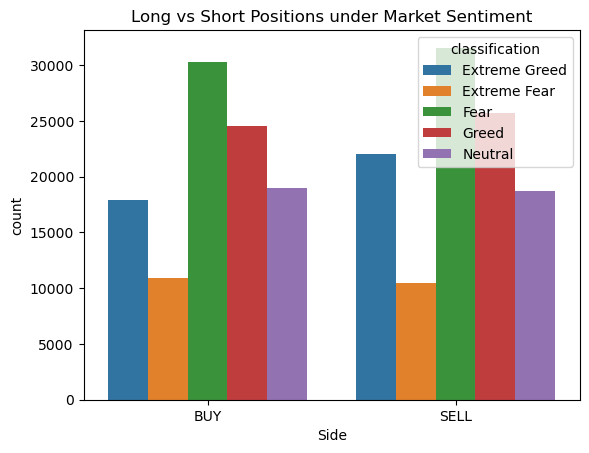

In [82]:
sns.countplot(x='Side', hue='classification', data=df)
plt.title("Long vs Short Positions under Market Sentiment")
plt.show()

### Strategy Recommendations

Based on the analysis, several actionable insights emerge:

1. **Reduce Risk During Fear Periods**
   Traders should reduce position sizes and avoid excessive trading during Fear periods due to higher volatility and downside risk.

2. **Capitalize on Momentum During Greed**
   Greed periods show higher trading activity and profitability potential. Traders may benefit from momentum-based strategies during these phases.

3. **Monitor Position Sizes**
   Larger trade sizes during Greed markets indicate higher risk-taking behavior. Proper risk management strategies should be implemented to avoid large drawdowns.

### Trader Behavioral Clustering (Bonus Analysis)

To identify different trading styles, traders are clustered based on behavioral metrics such as:

- Trade frequency
- Average trade size
- Total profit/loss

This helps identify distinct trader archetypes.

In [52]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

trader_features = df.groupby('Account').agg({
    'Closed PnL':'sum',
    'Size USD':'mean',
    'Account':'count'
}).rename(columns={'Account':'trade_count'}).reset_index()

scaler = StandardScaler()
X = scaler.fit_transform(trader_features[['Closed PnL','Size USD','trade_count']])

kmeans = KMeans(n_clusters=3, random_state=42)
trader_features['cluster'] = kmeans.fit_predict(X)

trader_features.head()

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Account,Closed PnL,Size USD,trade_count,cluster
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,16159.576734,3818,0
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,1653.226327,7280,1
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,8893.000898,3809,1
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,507.626933,13311,1
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,3138.894782,3239,1


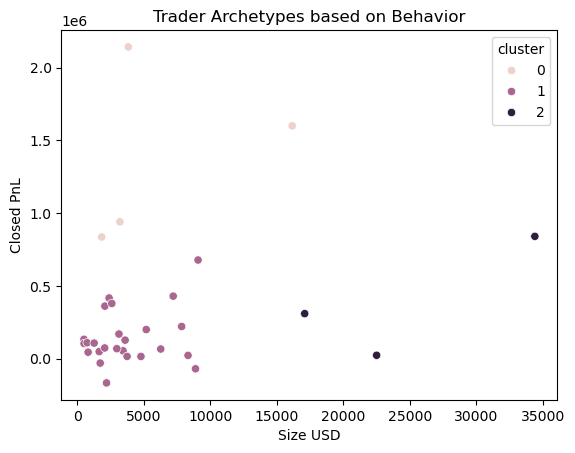

In [53]:
sns.scatterplot(
    x='Size USD',
    y='Closed PnL',
    hue='cluster',
    data=trader_features
)
plt.title("Trader Archetypes based on Behavior")
plt.show()

#### Cluster Interpretation

The clustering analysis reveals three main trader archetypes:

1. High-frequency traders with moderate profits
2. Low-frequency traders with larger position sizes
3. Traders with inconsistent performance

These behavioral groups provide insights into different trading strategies used by market participants.

### Strategy Rules Based on Findings

Based on the analysis of trader behavior and market sentiment, the following practical strategy rules can be proposed.

### Strategy Rule 1: Reduce Risk Exposure During Fear Markets
During Fear or Extreme Fear periods, traders tend to experience wider loss distributions and lower win rates. This suggests higher uncertainty and market volatility.

**Rule:**  
When market sentiment shifts to Fear, traders should reduce trade size and avoid excessive trading frequency. Smaller position sizes and stricter risk management can help prevent large losses.

---

### Strategy Rule 2: Utilize Momentum During Greed Markets
Greed and Extreme Greed periods show increased trading activity and higher profit opportunities.

**Rule:**  
During Greed sentiment regimes, traders may benefit from momentum-based strategies such as trend-following or increased trading frequency. However, risk management should still be maintained to avoid overexposure.

### Conclusion

This analysis shows that market sentiment plays a significant role in influencing trader behavior and performance.

Key findings include:
- Increased trading activity during Greed periods
- Higher risk exposure through larger trade sizes
- Behavioral differences among trader segments

Understanding these patterns can help traders adapt strategies based on prevailing market sentiment and manage risk more effectively.

### Limitations and Future Improvements

This analysis has several limitations:

- The study uses only historical trade data without considering external market factors.
- Sentiment is analyzed at a daily level, while trading occurs at higher frequency.
- Additional metrics such as leverage or portfolio exposure could further enhance the analysis.

Future work could include building predictive models to forecast trader profitability based on sentiment and behavioral features.